# Titanic Exploratory Data Analysis (EDA)
### Data Science Internship Project – Hex Softwares

Author: Yash Daitkar

This notebook performs Exploratory Data Analysis on the Titanic dataset to understand patterns that influenced passenger survival.

## 1. Introduction

The Titanic dataset contains information about passengers who were aboard the RMS Titanic during its voyage in 1912. The dataset includes demographic and travel-related features such as passenger age, gender, ticket class, fare paid, and whether the passenger survived.

The objective of this project is to perform Exploratory Data Analysis (EDA) to understand the structure of the dataset, identify patterns, and analyze which factors influenced passenger survival.

EDA is an important step in Data Science because it helps analysts summarize the dataset, detect missing values, visualize relationships between variables, and generate insights before applying machine learning models.

## 2. Import Required Libraries

The following Python libraries are used in this project:

- **Pandas** – for data manipulation and analysis
- **NumPy** – for numerical operations
- **Matplotlib** – for data visualization
- **Seaborn** – for advanced statistical visualizations

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Load the Dataset

The dataset is loaded using the Pandas library. It is assumed that the file `Titanic-Dataset.csv` is located in the same directory as this notebook.

In [6]:
df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 4. Dataset Overview

Before analyzing the data, it is important to understand its structure.

Key features in the dataset include:

- PassengerId: Unique identifier for each passenger
- Survived: Survival status (0 = Did not survive, 1 = Survived)
- Pclass: Passenger class (1 = First class, 2 = Second class, 3 = Third class)
- Name: Passenger name
- Sex: Gender of the passenger
- Age: Age of the passenger
- SibSp: Number of siblings/spouses aboard
- Parch: Number of parents/children aboard
- Ticket: Ticket number
- Fare: Ticket price
- Cabin: Cabin number
- Embarked: Port of embarkation

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 5. Checking Missing Values

Missing values are common in real-world datasets. Identifying and handling them is an important part of data preprocessing.

In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## 6. Data Cleaning

The following steps are performed to clean the dataset:

- Missing values in the **Age** column are replaced with the average age.
- Missing values in the **Embarked** column are replaced with the most frequent value.
- The **Cabin** column is removed because it contains too many missing values.

In [9]:
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin'], inplace=True)

df.isnull().sum()

/tmp/ipykernel_426/1007082608.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_426/1007082608.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## 7. Statistical Summary

Statistical analysis provides an overview of numerical features such as mean, standard deviation, minimum and maximum values.

In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 8. Survival Distribution

This visualization shows how many passengers survived versus those who did not survive.

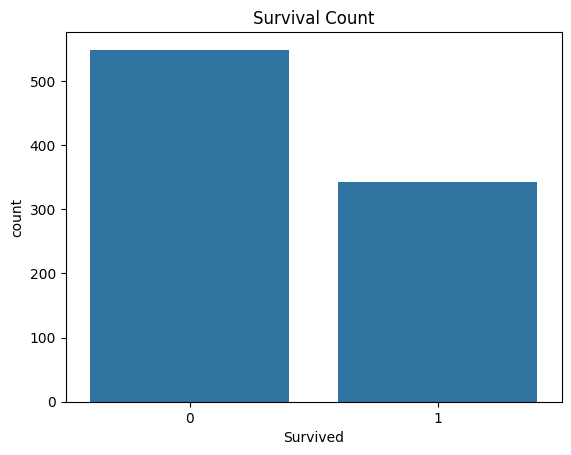

In [11]:
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.show()

## 9. Survival by Gender

This visualization compares survival rates between male and female passengers.

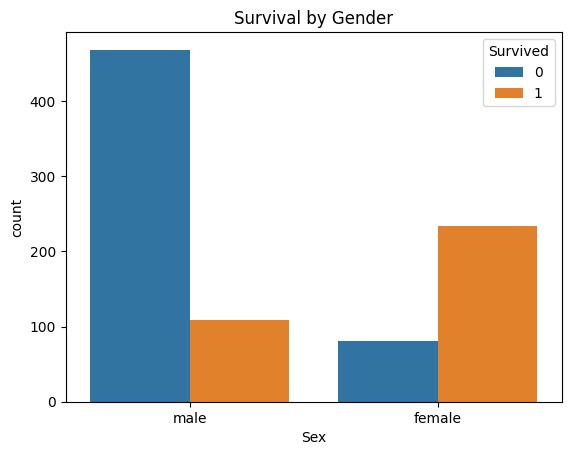

In [12]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.show()

## 10. Age Distribution

The histogram below shows how passenger ages are distributed.

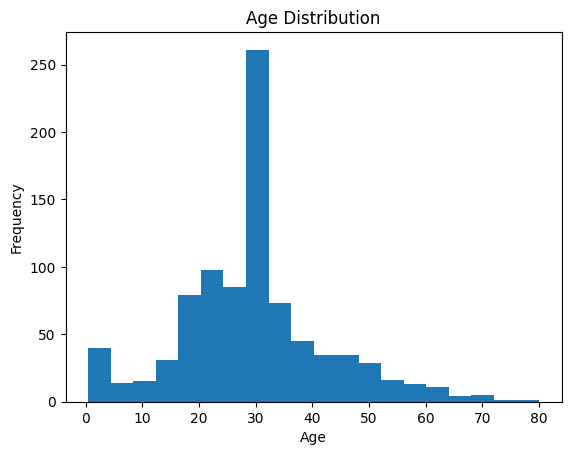

In [13]:
plt.hist(df['Age'], bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

## 11. Correlation Heatmap

A correlation heatmap helps identify relationships between numerical variables.

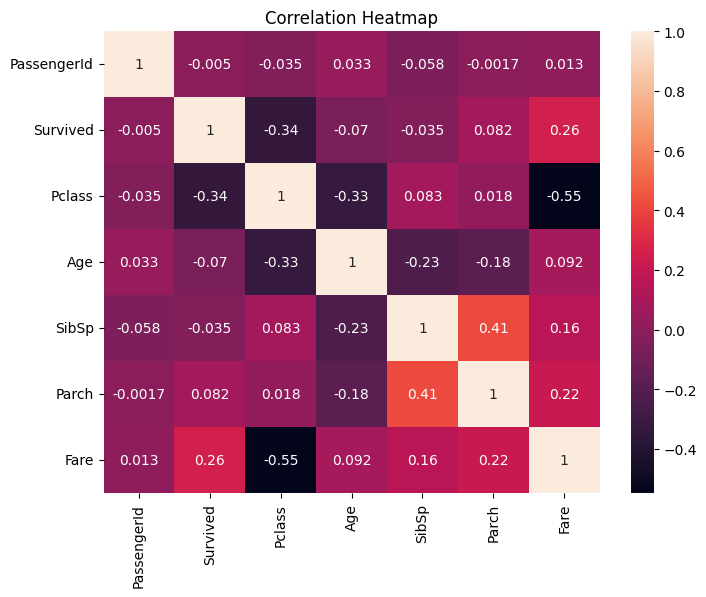

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap')
plt.show()

## 12. Key Insights

From the exploratory analysis, the following insights were observed:

1. Female passengers had a higher survival rate compared to male passengers.
2. Passengers traveling in first class had better survival chances.
3. The majority of passengers were between 20 and 40 years old.
4. Ticket fare and passenger class appear to influence survival probability.
5. Data visualization helped reveal patterns that are not immediately visible in raw data.

## 13. Conclusion

This project demonstrated how Exploratory Data Analysis can be used to understand a dataset and extract meaningful insights.

By cleaning the data and visualizing key features, we identified patterns related to passenger survival on the Titanic. EDA is a crucial step in the data science workflow as it helps analysts better understand their data before applying predictive models.